# Notebook 13: Statistical Data Visualization

**Sprint 2: Statistics & Mathematics for AI/ML Engineers**

---

## What is Statistical Visualization?

Statistical visualization means **showing data as pictures** so that patterns, spread, relationships and outliers become visible in seconds. A table of 500 rows is hard to read, but one chart can show the shape of the whole data.

**Analogy:** A doctor does not read a list of numbers from an ECG machine. The machine draws a line, and the doctor spots the problem at a glance.

**Why it matters in AI/ML:** Charts are the main tool of EDA (Exploratory Data Analysis). They help us check distributions (skewness, outliers), find relationships between features, compare groups, and explain results to non-technical people. The wrong chart can also mislead, so choosing the right one is a skill.

**Charts covered:** Histogram, Bar Chart, Line Chart, Scatter Plot, Pie Chart, Density Plot, Box Plot, Violin Plot, Pair Plot, Heatmap.

## Quick Guide: Which Chart to Use?

| Question | Chart |
|---|---|
| How is one numeric variable distributed? | Histogram, Density plot |
| How do categories compare? | Bar chart |
| How does a value change over time? | Line chart |
| How are two numeric variables related? | Scatter plot |
| What share does each category hold? | Pie chart (few categories) or Bar chart |
| Compare spread and outliers across groups? | Box plot |
| Compare full distribution shapes across groups? | Violin plot, Density plot |
| Relationships among many numeric variables? | Pair plot, Correlation heatmap |
| Values across two categories or a matrix? | Heatmap |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
np.random.seed(42)

n = 500
age = np.random.normal(35, 10, n).clip(18, 70)
income = np.random.lognormal(mean=10.5, sigma=0.5, size=n)          # right-skewed
segment = np.random.choice(["Regular", "Premium", "VIP"], n, p=[0.6, 0.3, 0.1])
city = np.random.choice(["Chennai", "Madurai", "Trichy", "Coimbatore"], n, p=[0.4, 0.2, 0.2, 0.2])

multiplier = pd.Series(segment).map({"Regular": 1.0, "Premium": 1.8, "VIP": 3.0}).values
spend = (0.04 * income * multiplier + np.random.normal(0, 300, n)).clip(0, None)

df = pd.DataFrame({"age": age, "income": income, "spend": spend,
                   "segment": segment, "city": city})

# Time series data (monthly sales)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
sales = 100 + 5 * np.arange(12) + 20 * np.sin(np.arange(12) * np.pi / 6) + np.random.normal(0, 6, 12)

print(df.head())
print("\nShape:", df.shape)
print("\nColumn types:\n", df.dtypes)

         age        income        spend  segment        city
0  39.967142  57704.403905  2215.413433  Regular      Trichy
1  33.617357  94344.506106  3548.133323  Regular     Chennai
2  41.476885  18046.665558  1395.112273  Premium     Chennai
3  50.230299  48121.513314  3866.884092  Premium     Chennai
4  32.658466  26230.515230   486.668868  Regular  Coimbatore

Shape: (500, 5)

Column types:
 age        float64
income     float64
spend      float64
segment        str
city           str
dtype: object


**Explanation:** We create a customer dataset with age, income (right-skewed), spend, segment and city, plus 12 months of sales. We will use the same data for every chart, so the charts can be compared easily.

**Interpretation:** `age`, `income` and `spend` are numeric (continuous). `segment` and `city` are categorical. The type of variable decides which chart is suitable: numeric variables go to histograms and scatter plots, and categorical variables go to bar charts.

## 1. Histogram

**Purpose:** Shows the **distribution of one numeric variable**. The values are divided into intervals (bins), and the height of each bar is the number of values in that bin.

**When to use:** To see the shape (symmetric or skewed), the center, the spread, gaps, and possible outliers of a numeric feature.

**Advantages:**
- Shows the full shape of the data, which mean and standard deviation cannot do
- Easy to read and quick to draw
- Helps decide on transformations (for example, log for right-skewed data)

**Limitations:**
- The shape depends on the **number of bins**: too few hide details, too many create noise
- Shows only one variable at a time
- Hard to compare many groups in one histogram

**Numerical Example:** Ages 21, 23, 24, 31, 33, 38, 42 with bins of width 10 (20-30, 30-40, 40-50) give counts 3, 3, 1.

**Business Example:** A retailer plots the histogram of bill amounts to see whether most bills are small with a few very large ones.

**AI/ML Example:** Checking whether a feature is skewed before scaling, and plotting model prediction errors (residuals) to see whether they look normal.

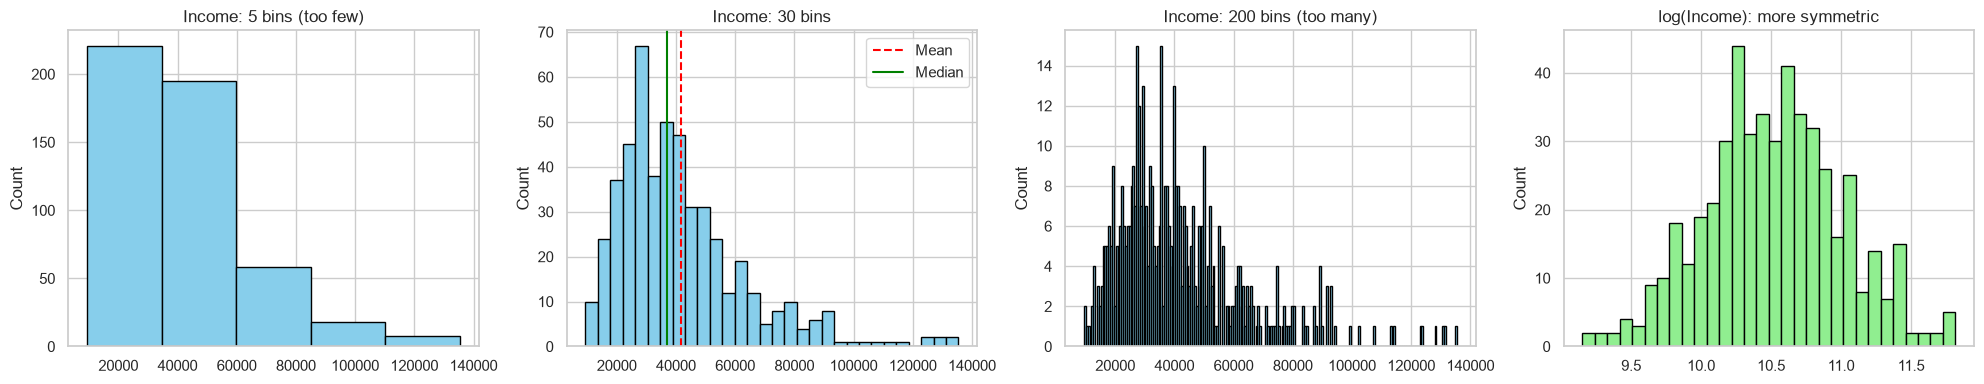

Skewness of income     : 1.47
Skewness of log(income): 0.05


In [2]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

axes[0].hist(df["income"], bins=5, color="skyblue", edgecolor="black")
axes[0].set_title("Income: 5 bins (too few)")

axes[1].hist(df["income"], bins=30, color="skyblue", edgecolor="black")
axes[1].axvline(df["income"].mean(), color="red", linestyle="--", label="Mean")
axes[1].axvline(df["income"].median(), color="green", label="Median")
axes[1].set_title("Income: 30 bins")
axes[1].legend()

axes[2].hist(df["income"], bins=200, color="skyblue", edgecolor="black")
axes[2].set_title("Income: 200 bins (too many)")

axes[3].hist(np.log(df["income"]), bins=30, color="lightgreen", edgecolor="black")
axes[3].set_title("log(Income): more symmetric")

for ax in axes:
    ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print("Skewness of income     :", round(stats.skew(df["income"]), 2))
print("Skewness of log(income):", round(stats.skew(np.log(df["income"])), 2))

**Explanation:** We draw the same income data with 5, 30 and 200 bins to show the effect of the bin count, and then a histogram of log(income). The mean (red) and median (green) are marked on the 30-bin chart.

**Interpretation:** With 5 bins the shape is too rough, and with 200 bins it is too noisy. Around 30 bins the right-skewed shape is clear: most customers have a lower income and a few have a very high income, so the mean is to the right of the median. After the log transform the shape becomes close to symmetric and the skewness is near 0. **Always try more than one bin size.**

## 2. Bar Chart

**Purpose:** Compares a **value across categories**. Each category has a bar, and the height shows the count, total or average.

**When to use:** Categorical variables (city, segment, product), comparing counts or averages, and ranking categories.

**Advantages:**
- Very easy to read, even for non-technical people
- Good for comparing many categories side by side
- Works for counts, sums, averages and percentages

**Limitations:**
- Shows only a summary (for example, the average) and hides the spread inside each group
- Many categories (above about 15) make it crowded
- A y-axis that does not start at 0 exaggerates differences

**Difference from histogram:** A histogram is for a **numeric** variable (bars touch each other, and bins are ranges). A bar chart is for **categories** (bars have gaps).

**Business Example:** Comparing the number of customers or the average spend in each city.

**AI/ML Example:** Checking the **class balance** of the target (for example, 2% fraud and 98% normal), and comparing accuracy of different models.

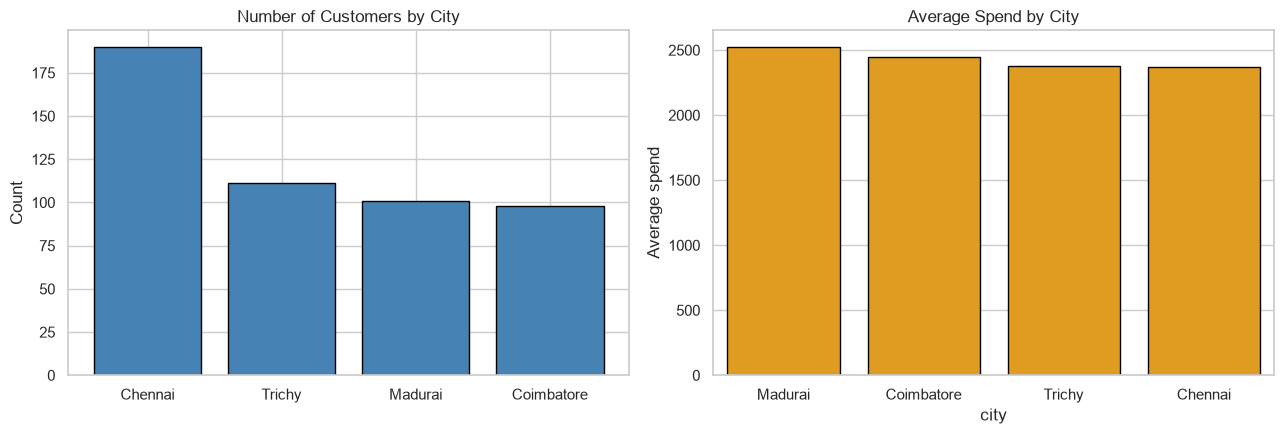

city
Chennai       190
Trichy        111
Madurai       101
Coimbatore     98
Name: count, dtype: int64

 city
Madurai       2525.0
Coimbatore    2446.0
Trichy        2379.0
Chennai       2367.0
Name: spend, dtype: float64


In [3]:
city_counts = df["city"].value_counts()
city_avg = df.groupby("city")["spend"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(city_counts.index, city_counts.values, color="steelblue", edgecolor="black")
axes[0].set_title("Number of Customers by City")
axes[0].set_ylabel("Count")

sns.barplot(x=city_avg.index, y=city_avg.values, color="orange", edgecolor="black", ax=axes[1])
axes[1].set_title("Average Spend by City")
axes[1].set_ylabel("Average spend")

plt.tight_layout()
plt.show()

print(city_counts)
print("\n", city_avg.round(0))

**Explanation:** The left chart counts customers per city using `value_counts()`. The right chart shows the average spend per city, calculated with `groupby().mean()`.

**Interpretation:** Chennai has the most customers (we gave it 40% of the data). The average spend is almost the same in all cities, so city alone does not explain spending. A bar chart shows **only the average**, so it cannot tell us whether the spend inside a city varies a lot. For that we use a box plot or a violin plot.

## 3. Line Chart

**Purpose:** Shows how a value **changes over time** (or over any ordered sequence). Points are joined by a line, so trends, seasonality and sudden changes are easy to see.

**When to use:** Time series (daily sales, monthly users, stock price) and training curves of ML models.

**Advantages:**
- Shows trend and direction clearly
- Can compare several series in one chart
- Shows seasonality and sudden jumps or drops

**Limitations:**
- Needs an ordered x-axis (time). It is wrong for unordered categories
- Many lines on one chart become messy
- Noisy data hides the trend (we smooth it with a moving average)

**Numerical Example:** Sales 100, 110, 105, 120. A 2-month moving average gives 105, 107.5, 112.5. It is less noisy than the original values.

**Business Example:** Monthly sales with a smoothed trend line, so management can see the growth direction.

**AI/ML Example:** **Learning curves**: training loss and validation loss against epochs. If validation loss starts rising while training loss keeps falling, the model is overfitting.

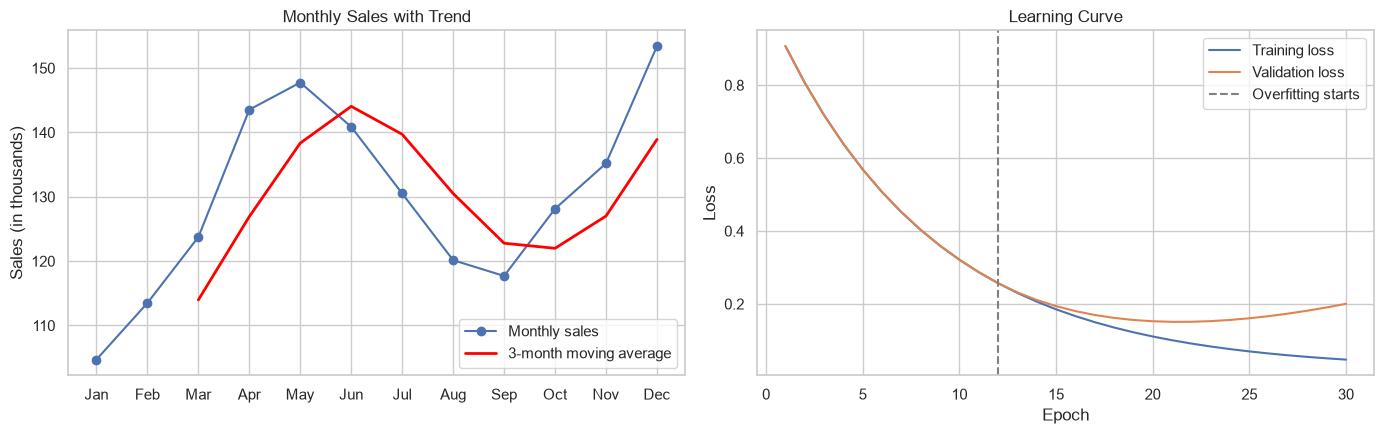

In [4]:
sales_series = pd.Series(sales, index=months)
trend = sales_series.rolling(window=3).mean()

# Simple ML learning-curve example
epochs = np.arange(1, 31)
train_loss = 1.0 * np.exp(-0.12 * epochs) + 0.02
val_loss = 1.0 * np.exp(-0.12 * epochs) + 0.02 + 0.0015 * np.maximum(epochs - 12, 0) ** 1.6

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(months, sales_series.values, marker="o", label="Monthly sales")
axes[0].plot(months, trend.values, color="red", linewidth=2, label="3-month moving average")
axes[0].set_title("Monthly Sales with Trend")
axes[0].set_ylabel("Sales (in thousands)")
axes[0].legend()

axes[1].plot(epochs, train_loss, label="Training loss")
axes[1].plot(epochs, val_loss, label="Validation loss")
axes[1].axvline(12, color="gray", linestyle="--", label="Overfitting starts")
axes[1].set_title("Learning Curve")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

**Explanation:** The left chart draws monthly sales and a 3-month moving average (`rolling(3).mean()`). The right chart is a typical learning curve of a model, drawn with training and validation loss.

**Interpretation:** Sales go up over the year with some ups and downs, and the red line makes the upward trend clear. In the learning curve, both losses fall at first. After about epoch 12 the validation loss starts to rise while the training loss keeps falling, which is the sign of **overfitting**, so we should stop training near that point (early stopping).

## 4. Scatter Plot

**Purpose:** Shows the **relationship between two numeric variables**. Each point is one observation, with x and y positions.

**When to use:** To see correlation (positive, negative, none), curved patterns, clusters, and outliers in two variables. A third variable can be shown with colour or size.

**Advantages:**
- Shows the real shape of a relationship (linear, curved, clusters), which a correlation number cannot do
- Finds outliers and unusual points, including multivariate outliers
- Colour can show groups

**Limitations:**
- With thousands of points, points overlap (use transparency `alpha` or hexbin)
- Shows only two variables at a time
- Shows association, not cause and effect

**Business Example:** Plotting advertising spend against sales to see whether more advertising goes with more sales.

**AI/ML Example:** Plotting each feature against the target before regression, and plotting predicted values against actual values to judge a model (points near the diagonal mean good predictions).

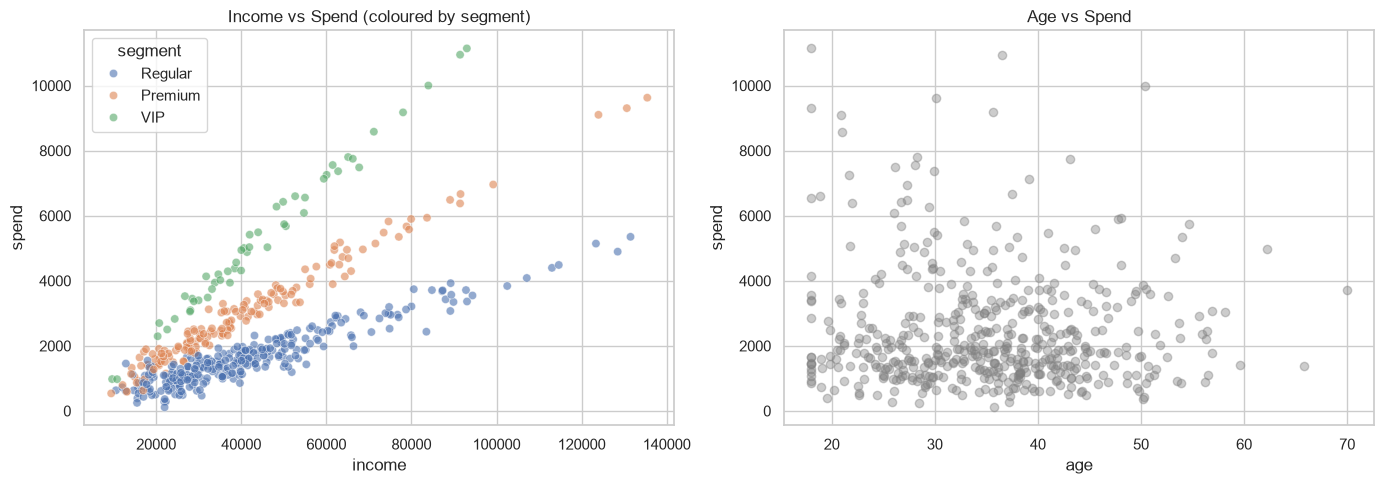

Correlation income-spend: 0.708
Correlation age-spend   : -0.06


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="income", y="spend", hue="segment", alpha=0.6, ax=axes[0])
axes[0].set_title("Income vs Spend (coloured by segment)")

axes[1].scatter(df["age"], df["spend"], alpha=0.4, color="gray")
axes[1].set_title("Age vs Spend")
axes[1].set_xlabel("age")
axes[1].set_ylabel("spend")

plt.tight_layout()
plt.show()

print("Correlation income-spend:", round(df["income"].corr(df["spend"]), 3))
print("Correlation age-spend   :", round(df["age"].corr(df["spend"]), 3))

**Explanation:** The left chart plots income against spend and uses colour for the segment. The right chart plots age against spend. We also print the Pearson correlation of each pair.

**Interpretation:** Income and spend show a clear positive relationship. The points form three separate "fans", one for each segment, because VIP and Premium customers spend more for the same income. A single correlation number would hide this group structure. Age against spend is a shapeless cloud with a correlation close to 0, so age is not useful for predicting spend here.

## 5. Pie Chart

**Purpose:** Shows the **share (percentage) of each category** in a whole. The full circle is 100%.

**When to use:** Only when there are **few categories (about 2 to 5)**, the parts add up to a meaningful whole, and the goal is to show the rough share of each part.

**Advantages:**
- Quick, familiar and good for showing "one part is big" or "roughly half"
- Easy to understand for a general audience

**Limitations:**
- Humans are poor at comparing angles and areas, so similar slices are hard to compare
- Becomes unreadable with many categories
- Cannot show negative values or values that do not add up to a whole
- A bar chart is almost always easier to read

**Numerical Example:** Segment counts of 300, 150 and 50 out of 500 give shares of 60%, 30% and 10%.

**Business Example:** Share of revenue from each product line in a company report.

**AI/ML Example:** Showing the class distribution of a target (for example, 95% normal and 5% fraud) in a report, though a bar chart is usually better in a notebook.

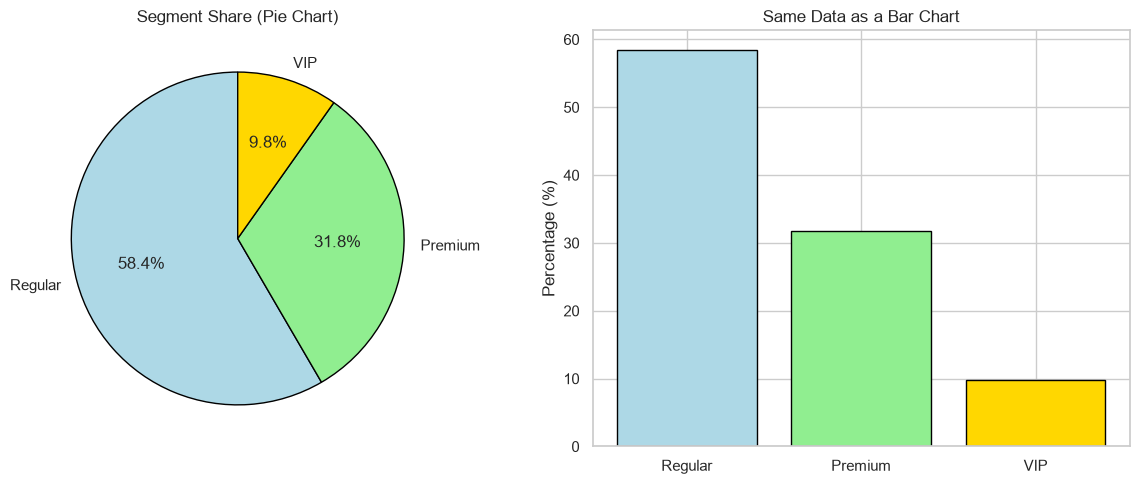

In [6]:
seg_counts = df["segment"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(seg_counts.values, labels=seg_counts.index, autopct="%1.1f%%",
            startangle=90, colors=["lightblue", "lightgreen", "gold"],
            wedgeprops={"edgecolor": "black"})
axes[0].set_title("Segment Share (Pie Chart)")

axes[1].bar(seg_counts.index, seg_counts.values / seg_counts.sum() * 100,
            color=["lightblue", "lightgreen", "gold"], edgecolor="black")
axes[1].set_title("Same Data as a Bar Chart")
axes[1].set_ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

**Explanation:** `plt.pie()` draws the share of each segment, and `autopct` prints the percentages. The second chart shows the same data as a bar chart.

**Interpretation:** Regular customers are about 60%, Premium about 30% and VIP about 10%. The pie chart is fine here because there are only 3 categories with clearly different sizes. If two slices were 31% and 33%, we could not tell which is bigger by the angle, but the bar chart would show it immediately. **Rule of thumb: when in doubt, use a bar chart.**

## 6. Density Plot (KDE)

**Purpose:** A **smooth version of the histogram**. It estimates the probability density using Kernel Density Estimation (KDE), so the area under the curve is 1.

**When to use:** To see the shape of a distribution without choosing bins, and to **compare several groups** by drawing their curves in one chart.

**Advantages:**
- Smooth shape, and no bin-size problem
- Easy to overlay many groups
- Shows peaks (modes), including two peaks (bimodal)

**Limitations:**
- The smoothness depends on the **bandwidth**: too wide hides peaks, too narrow gives noise
- Can show density in places where no data exists (for example, negative spend)
- Hard to explain to non-technical audiences, and unreliable for very small samples

**Business Example:** Comparing the spending distribution of Regular, Premium and VIP customers in a single chart.

**AI/ML Example:** Comparing a feature's distribution in the **training data and production data** to detect data drift. Also comparing a feature for the two classes to see whether it separates them.

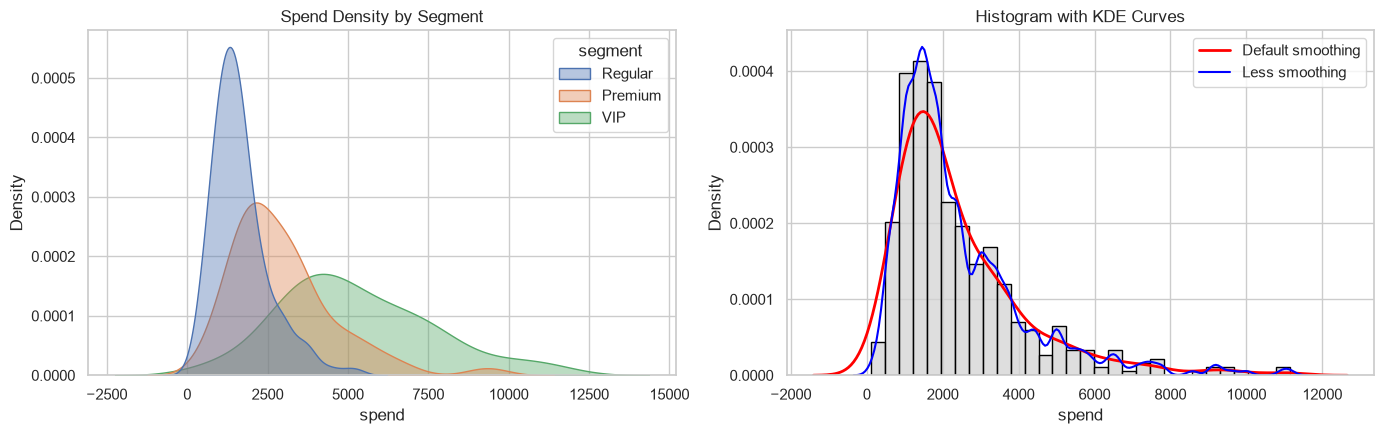

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.kdeplot(data=df, x="spend", hue="segment", fill=True, common_norm=False,
            alpha=0.4, ax=axes[0])
axes[0].set_title("Spend Density by Segment")

sns.histplot(df["spend"], bins=30, stat="density", color="lightgray", edgecolor="black", ax=axes[1])
sns.kdeplot(df["spend"], color="red", linewidth=2, ax=axes[1], label="Default smoothing")
sns.kdeplot(df["spend"], color="blue", bw_adjust=0.3, linewidth=1.5, ax=axes[1], label="Less smoothing")
axes[1].set_title("Histogram with KDE Curves")
axes[1].legend()

plt.tight_layout()
plt.show()

**Explanation:** `sns.kdeplot()` draws the smooth density curve. In the left chart `hue="segment"` draws one curve per segment, and `common_norm=False` makes each curve integrate to 1 on its own. The right chart lays a KDE over a histogram and shows how `bw_adjust` (bandwidth) changes the smoothness.

**Interpretation:** Regular customers have a narrow, low spend curve, and Premium and VIP curves are shifted to the right and are wider. So spending increases with the segment, and the groups overlap only a little. In the right chart, the blue curve (less smoothing) follows every small bump of the data, while the red curve gives the overall shape. **A density plot is a histogram without the bins.**

## 7. Box Plot

**Purpose:** Shows the **five-number summary** (minimum, Q1, median, Q3, maximum) and the **outliers** in one compact picture. The box is the IQR, the line inside is the median, whiskers extend to 1.5 x IQR, and dots beyond them are outliers.

**When to use:** To compare the center and spread of a numeric variable **across groups**, and to spot outliers quickly.

**Advantages:**
- Very compact, so many groups fit side by side
- Shows median, spread, skewness and outliers together
- Not affected by outliers (based on quartiles)

**Limitations:**
- Hides the shape of the distribution (a two-peak distribution can look like a normal box)
- Beginners often find it hard to read
- Does not show the number of observations

**Numerical Example:** Data 12, 15, 17, 18, 20, 22, 25, 27, 30, 35, 90 gives Q1 = 17.5, median = 22, Q3 = 28.5, IQR = 11, upper fence = 45, so 90 is plotted as an outlier dot.

**Business Example:** Comparing salary ranges of different departments, and spotting unusually high salaries.

**AI/ML Example:** Checking a feature for outliers during EDA (Notebook 9), and comparing a feature across target classes (for example, income for defaulters vs non-defaulters).

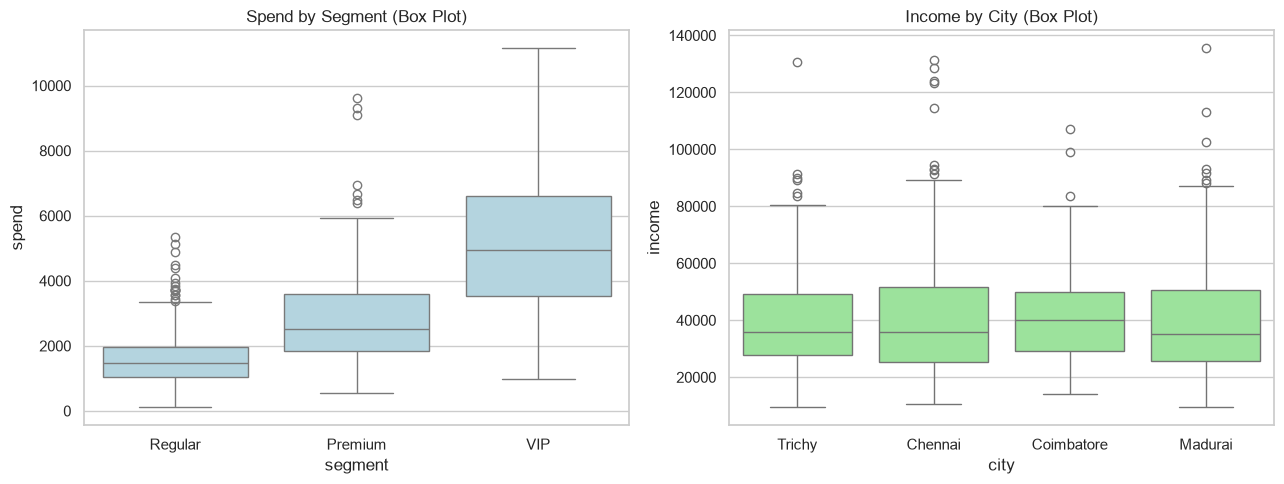

         count    mean     std    min     25%     50%     75%      max
segment                                                               
Premium  159.0  2953.0  1631.0  539.0  1848.0  2529.0  3586.0   9628.0
Regular  292.0  1645.0   887.0  111.0  1054.0  1471.0  1977.0   5352.0
VIP       49.0  5277.0  2338.0  976.0  3528.0  4944.0  6601.0  11143.0


In [8]:
order = ["Regular", "Premium", "VIP"]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="segment", y="spend", order=order, color="lightblue", ax=axes[0])
axes[0].set_title("Spend by Segment (Box Plot)")

sns.boxplot(data=df, x="city", y="income", color="lightgreen", ax=axes[1])
axes[1].set_title("Income by City (Box Plot)")

plt.tight_layout()
plt.show()

print(df.groupby("segment")["spend"].describe().round(0))

**Explanation:** We draw one box per group. The left chart compares spend across the three segments, and the right chart compares income across cities. `describe()` prints the numbers behind the boxes.

**Interpretation:** The median spend rises from Regular to Premium to VIP, and the VIP box is wider, so VIP spending varies more. Several dots above the whiskers are high-income or high-spend customers. In the income chart, all cities look almost the same (similar boxes and medians), and the dots above the whiskers are the natural right tail of the income distribution. **A dot is only a suspect, not automatically an error** (see Notebook 9).

## 8. Violin Plot

**Purpose:** A **box plot plus a density plot**. The width of the "violin" at each height shows how many values are there, so it shows both the summary statistics and the **full shape** of the distribution.

**When to use:** To compare distributions across groups when the **shape matters** (for example, a two-peak distribution that a box plot would hide).

**Advantages:**
- Shows shape, spread and median together
- Reveals multiple peaks (bimodal data) that a box plot misses
- Easy to compare groups side by side

**Limitations:**
- Harder to read for non-technical people
- The smooth shape depends on the KDE bandwidth, and it can extend beyond the real data range
- Can mislead with very small groups

**Business Example:** Comparing the distribution of delivery times in different cities: a violin plot can show that one city has two groups of deliveries (fast and slow), which an average or a box plot would hide.

**AI/ML Example:** Comparing a model's prediction scores for the positive and negative classes, or the distribution of a feature across classes.

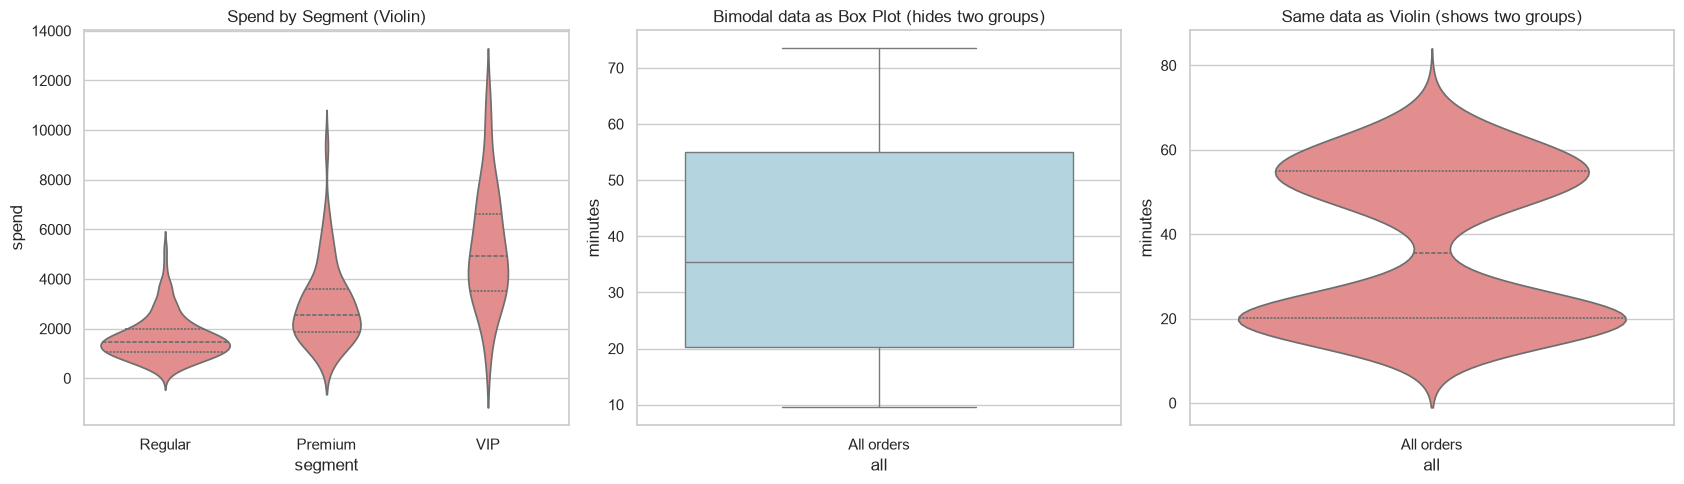

In [9]:
# A bimodal example: delivery time has two groups (local and outstation)
np.random.seed(42)
delivery = np.concatenate([np.random.normal(20, 4, 250), np.random.normal(55, 6, 250)])
delivery_df = pd.DataFrame({"minutes": delivery, "all": "All orders"})

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.violinplot(data=df, x="segment", y="spend", order=order, inner="quartile",
               color="lightcoral", ax=axes[0])
axes[0].set_title("Spend by Segment (Violin)")

sns.boxplot(data=delivery_df, x="all", y="minutes", color="lightblue", ax=axes[1])
axes[1].set_title("Bimodal data as Box Plot (hides two groups)")

sns.violinplot(data=delivery_df, x="all", y="minutes", inner="quartile",
               color="lightcoral", ax=axes[2])
axes[2].set_title("Same data as Violin (shows two groups)")

plt.tight_layout()
plt.show()

**Explanation:** The first chart is a violin plot of spend by segment, where the lines inside show the quartiles. Then we create delivery times with two groups (about 20 minutes and about 55 minutes) and draw the same data as a box plot and as a violin plot.

**Interpretation:** The violins show that VIP spend is wide and spread out, while Regular spend is narrow and concentrated. For the delivery time, the **box plot looks like one ordinary box** with the median between the two groups, where almost no orders actually exist. The **violin shows two clear bulges**, which tells us that there are two kinds of deliveries. This is the main reason to use a violin plot: **it shows the shape that summary statistics hide**.

| | Box plot | Violin plot |
|---|---|---|
| Shows quartiles and outliers | Yes, clearly | Yes, less clearly |
| Shows shape and multiple peaks | No | Yes |
| Easy for beginners | Yes | Slightly harder |

## 9. Pair Plot

**Purpose:** Draws a **grid of scatter plots for every pair of numeric variables**, with the **histogram or density of each variable on the diagonal**. It gives an overview of the whole dataset in one figure.

**When to use:** At the start of EDA with a small or medium number of numeric features (about 3 to 8), to see relationships, distributions and groups together.

**Advantages:**
- One chart shows all pairwise relationships and all distributions
- With `hue`, shows how a categorical variable (or the target class) separates the data
- Quickly finds correlated features, outliers and non-linear patterns

**Limitations:**
- With many features the grid becomes huge and slow (n features make n x n plots)
- Shows only pairs, so it can miss relationships among three or more variables
- Points overlap when the data is large

**Business Example:** An analyst looks at age, income and spend together and sees which pairs are related and which customer groups separate.

**AI/ML Example:** In classification, a pair plot coloured by the target class (like the famous Iris dataset plot) quickly shows which features separate the classes.

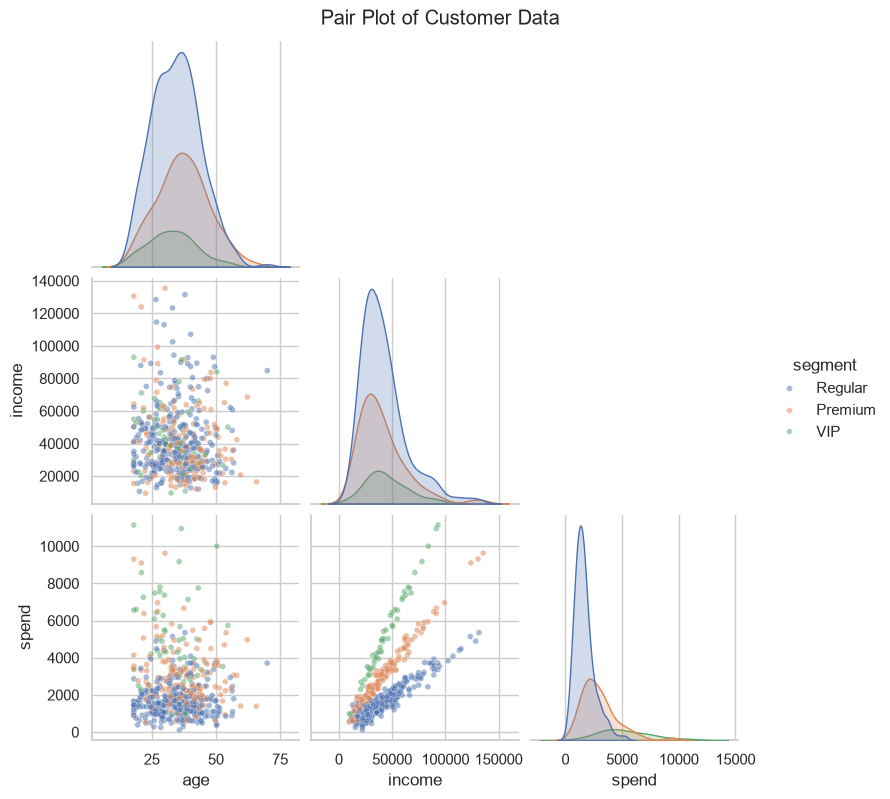

In [10]:
g = sns.pairplot(df[["age", "income", "spend", "segment"]], hue="segment",
                 hue_order=order, corner=True,
                 plot_kws={"alpha": 0.5, "s": 18}, height=2.6)
g.figure.suptitle("Pair Plot of Customer Data", y=1.02)
plt.show()

**Explanation:** `sns.pairplot()` draws every pair of `age`, `income` and `spend`, coloured by `segment`. The diagonal shows the distribution of each variable. `corner=True` removes the repeated upper half.

**Interpretation:** In the `income` vs `spend` panel, the three segments form three separate fans, so income and segment together explain spend well. The `age` panels are shapeless clouds, which means age has no link with income or spend. The diagonal for `income` is right-skewed. In one picture we found the useful features (income, segment), the useless feature (age), and the skewed variable (income, which may need a log transform).

## 10. Heatmap

**Purpose:** Shows a **matrix of values as colours**. The colour intensity shows how big each value is, so patterns appear without reading numbers.

**When to use:** Correlation matrices, a table of values for two categories (for example, average spend by city and segment), confusion matrices, and time vs category tables (hour of day vs day of week).

**Advantages:**
- Shows patterns across a big table at a glance
- Good for correlation matrices with many variables
- Colour scale makes high and low values obvious

**Limitations:**
- Colours are less precise than numbers (so we add numbers with `annot=True`)
- A wrong colour scale (not centred at 0 for correlation) misleads
- Hard to read with very large matrices

**Business Example:** Average spend by city and segment, to see which city-segment combination is the most valuable.

**AI/ML Example:** The **correlation heatmap** (Notebooks 8 and 12) for feature selection, and the **confusion matrix heatmap** to evaluate a classifier.

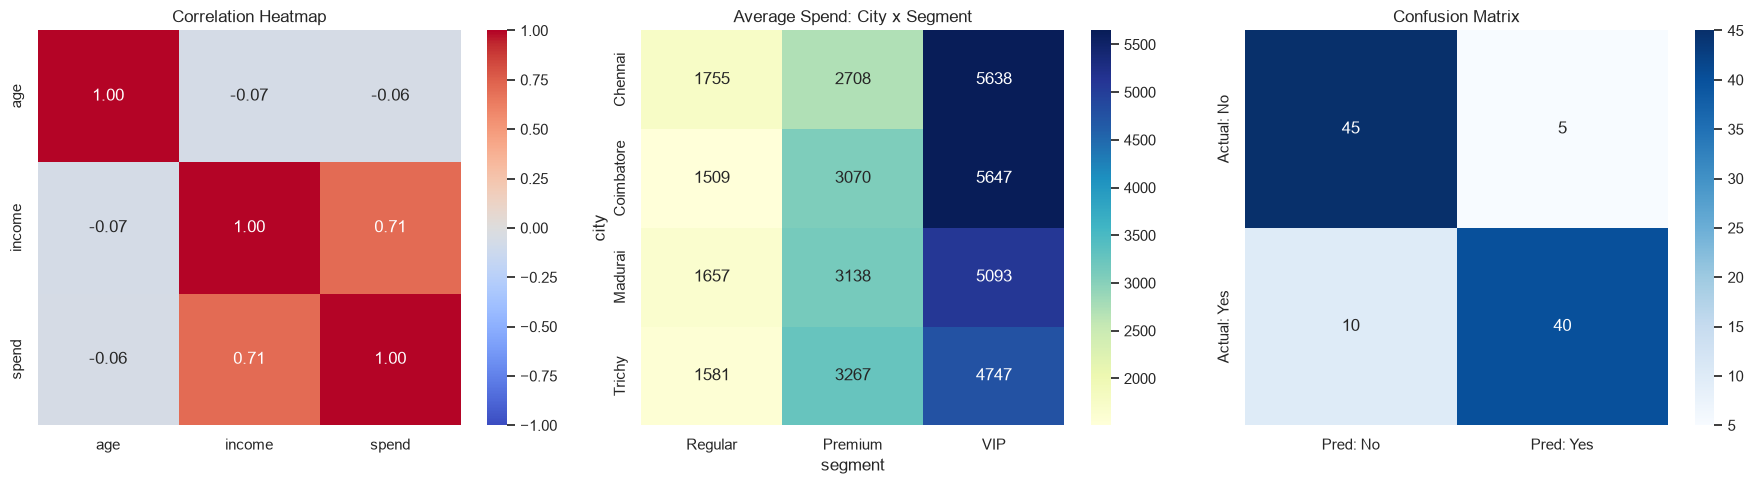

In [11]:
corr = df[["age", "income", "spend"]].corr()
pivot = df.pivot_table(values="spend", index="city", columns="segment", aggfunc="mean")[order]

# Simple confusion matrix example (a classifier on 100 test samples)
conf = np.array([[45, 5],
                 [10, 40]])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlation Heatmap")

sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[1])
axes[1].set_title("Average Spend: City x Segment")

sns.heatmap(conf, annot=True, fmt="d", cmap="Blues", ax=axes[2],
            xticklabels=["Pred: No", "Pred: Yes"], yticklabels=["Actual: No", "Actual: Yes"])
axes[2].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

**Explanation:** `sns.heatmap()` colours a matrix. The first is a correlation matrix (colour scale fixed from -1 to +1 with `vmin` and `vmax`). The second is a pivot table of the average spend for every city and segment combination. The third is a confusion matrix, where darker cells mean more samples.

**Interpretation:**
- **Correlation:** `income` and `spend` are strongly positive (dark red), and `age` is near 0 with everything (pale).
- **City x Segment:** colour grows from Regular to VIP in **every** city, and the rows are similar, so the segment matters much more than the city.
- **Confusion matrix:** the diagonal (45 and 40) is the correct predictions, and the off-diagonal (5 and 10) are the errors, so the accuracy is (45 + 40) / 100 = 85%.

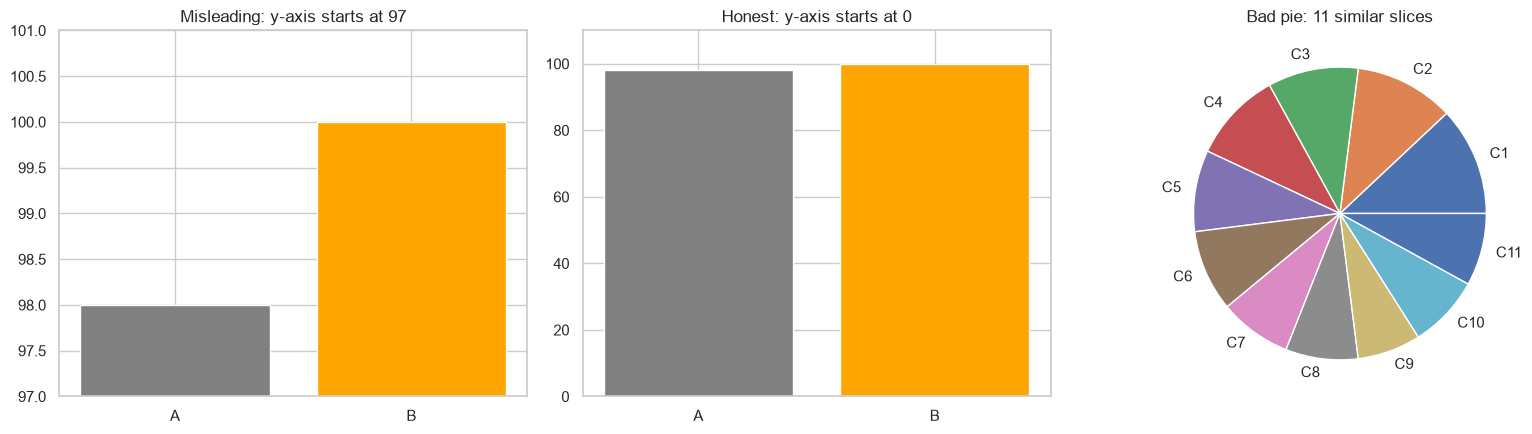

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Truncated y-axis exaggerates a tiny difference
vals = [98, 100]
axes[0].bar(["A", "B"], vals, color=["gray", "orange"])
axes[0].set_ylim(97, 101)
axes[0].set_title("Misleading: y-axis starts at 97")

axes[1].bar(["A", "B"], vals, color=["gray", "orange"])
axes[1].set_ylim(0, 110)
axes[1].set_title("Honest: y-axis starts at 0")

# 2. Pie chart with many similar slices
sizes = [12, 11, 10, 10, 9, 9, 8, 8, 7, 8, 8]
axes[2].pie(sizes, labels=[f"C{i+1}" for i in range(len(sizes))])
axes[2].set_title("Bad pie: 11 similar slices")

plt.tight_layout()
plt.show()

**Explanation:** We draw two common mistakes: a bar chart whose y-axis does not start at 0, and a pie chart with too many similar slices.

**Interpretation:** In the first chart, B looks like several times bigger than A, but the real difference is only 2%. The honest chart shows they are almost equal. The pie chart with 11 slices is unreadable, because we cannot rank the slices. **A chart should help the reader understand the truth, not create a wrong impression.**

**Good chart checklist:** a clear title, labelled axes with units, a suitable chart type, a y-axis starting at 0 for bar charts, readable colours, and no unnecessary decoration.`

## Summary: Which Chart to Use?

| Chart | Variables | Shows | Best used when | Main limitation |
|---|---|---|---|---|
| Histogram | 1 numeric | Distribution shape | Checking skewness, outliers | Depends on the bin size |
| Bar chart | 1 categorical (+ value) | Comparison of categories | Counts, averages, ranking | Hides the spread in each group |
| Line chart | Time + numeric | Trend over time | Time series, learning curves | Needs ordered x-axis |
| Scatter plot | 2 numeric | Relationship | Correlation, clusters, outliers | Overlap with large data |
| Pie chart | 1 categorical | Share of a whole | Few categories (2 to 5) | Hard to compare angles |
| Density plot | 1 numeric | Smooth distribution | Comparing groups, drift checks | Depends on the bandwidth |
| Box plot | Numeric by group | Median, IQR, outliers | Comparing groups, finding outliers | Hides the shape |
| Violin plot | Numeric by group | Full distribution shape | Shape matters, multiple peaks | Harder to read |
| Pair plot | Many numeric | All pairwise relationships | Starting EDA with few features | Slow with many features |
| Heatmap | Matrix | Values as colours | Correlation, pivot tables, confusion matrix | Less precise than numbers |

## Advantages
- Shows patterns, outliers and relationships that tables and summary numbers hide
- Fast way to explore data (EDA) and to decide on cleaning, transformation and features
- Makes results easy to explain to non-technical people
- Helps to check model behaviour (learning curves, residuals, confusion matrix)

## Limitations
- The wrong chart type or a wrong scale can mislead (truncated axis, too many pie slices)
- Visual patterns are subjective and need statistical confirmation (correlation, tests)
- Charts do not scale well to many variables or millions of points without aggregation or sampling
- A chart shows association, not cause and effect